High-Dimensional Data, Dimensionality Reduction & PCA
High-Dimensional Data
A dataset is said to be high-dimensional when it contains a very large number of features (columns/variables) compared to the number of observations (rows).

Examples
Low-dimensional data: 3 features such as Height, Weight, and Age.
High-dimensional data: 10,000 features such as gene expression levels for patients, image pixel values, or text embeddings.
What are High-Dimensional Spaces?
A high-dimensional space is simply the mathematical space where the data lives when it has many features (dimensions/variables).

Each feature in the dataset represents a dimension (axis).
A dataset with 2 features lives in a 2D space (you can plot it on a flat plane).
A dataset with 3 features lives in a 3D space (you can visualize it as a cube).
A dataset with 100 features lives in a 100-dimensional space (you cannot visualize this directly, but mathematically it exists).
Approaches to Dimensionality Reduction
A. Feature Selection
Feature selection reduces dimensionality by choosing a subset of the original features. It does not create new features.

Methods:

Filter methods: Select features based on statistical tests such as correlation, chi-square test, or ANOVA.
Wrapper methods: Use predictive models to evaluate subsets of features, e.g., forward selection, backward elimination, or recursive feature elimination (RFE).
Embedded methods: Select features as part of model training, e.g., LASSO regression, Decision Trees, or Random Forest feature importance.
B. Feature Extraction
Feature extraction reduces dimensionality by transforming the original features into a new set of features. These new features are usually fewer in number and more informative.

Methods:

Principal Component Analysis (PCA): A linear method that finds new axes (principal components) which capture maximum variance in the data.
Linear Discriminant Analysis (LDA): A supervised method that finds axes that maximize the separation between classes.
t-SNE (t-Distributed Stochastic Neighbor Embedding): A nonlinear method for visualizing high-dimensional data in 2D or 3D.
UMAP (Uniform Manifold Approximation and Projection): A nonlinear method that preserves both local and global structure in the data.
Autoencoders: Neural networks that learn to compress data into a lower-dimensional representation and reconstruct it back.
Principal Component Analysis (PCA)
What is PCA?
PCA is a dimensionality reduction technique that takes many original features and transforms them into a smaller number of new features called principal components.

The goal is to retain as much useful variation in the data as possible while reducing the number of dimensions.

Imagine we have a dataset containing information about customers applying for loans:

Annual income (KES)
Loan amount (KES)
Monthly repayment (KES)
Notice that these features may be related. Customers with higher incomes may qualify for larger loans and have larger repayments.

This means some of the features contain overlapping information.

PCA attempts to combine such information into fewer dimensions.

In [1]:
import pandas as pd
import numpy as np
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
import matplotlib.pyplot as plt

In [2]:
data = load_iris()
X = pd.DataFrame(data.data, columns=data.feature_names)
y = pd.Series(data.target)

In [3]:
# Display the first few rows
print("First 5 rows of the dataset:")
print(X.head())

First 5 rows of the dataset:
   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)
0                5.1               3.5                1.4               0.2
1                4.9               3.0                1.4               0.2
2                4.7               3.2                1.3               0.2
3                4.6               3.1                1.5               0.2
4                5.0               3.6                1.4               0.2


In [4]:
X.shape

(150, 4)

In [5]:
# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Standardize the features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [6]:
# fit PCA with all components (so we can inspect explained variance)
pca_full = PCA()                        # n_components=None -> all components
pca_full.fit(X_train_scaled)

explained_var = pca_full.explained_variance_ratio_
print("Explained variance ratio (per PC):", np.round(explained_var, 4))
print("Cumulative explained variance:", np.round(np.cumsum(explained_var), 4))

Explained variance ratio (per PC): [0.7255 0.23   0.0396 0.0049]
Cumulative explained variance: [0.7255 0.9555 0.9951 1.    ]


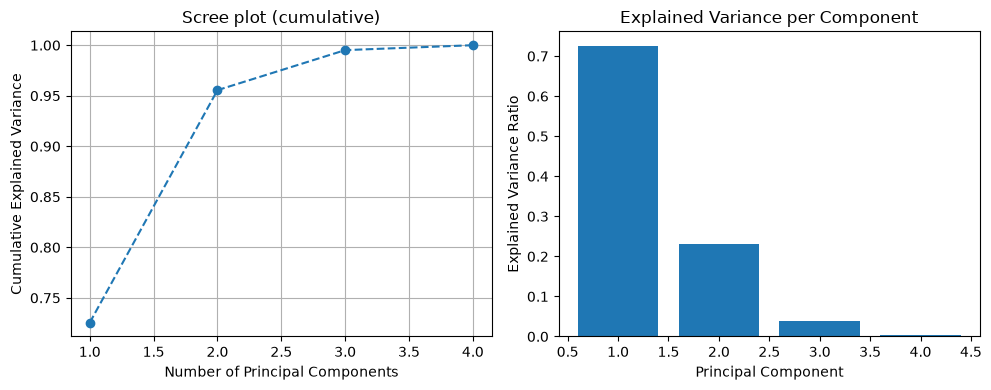

In [7]:
# scree & bar plot
plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.plot(np.arange(1, len(explained_var)+1), np.cumsum(explained_var),
         marker='o', linestyle='--')
plt.xlabel('Number of Principal Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('Scree plot (cumulative)')
plt.grid(True)

plt.subplot(1,2,2)
plt.bar(np.arange(1, len(explained_var)+1), explained_var)
plt.xlabel('Principal Component')
plt.ylabel('Explained Variance Ratio')
plt.title('Explained Variance per Component')

plt.tight_layout()
plt.show()

In [8]:
#choose number of components to retain 95% variance
threshold = 0.95
cumvar = np.cumsum(explained_var)
n_needed = np.argmax(cumvar >= threshold) + 1
print(f"Number of components to retain >= {threshold*100:.0f}% variance: {n_needed}")

Number of components to retain >= 95% variance: 2


In [9]:
# fit PCA with chosen number of components 
n_components = n_needed  
pca = PCA(n_components=n_components)
X_train_pca = pca.fit_transform(X_train_scaled)  # fit on train
X_test_pca  = pca.transform(X_test_scaled)       # transform test

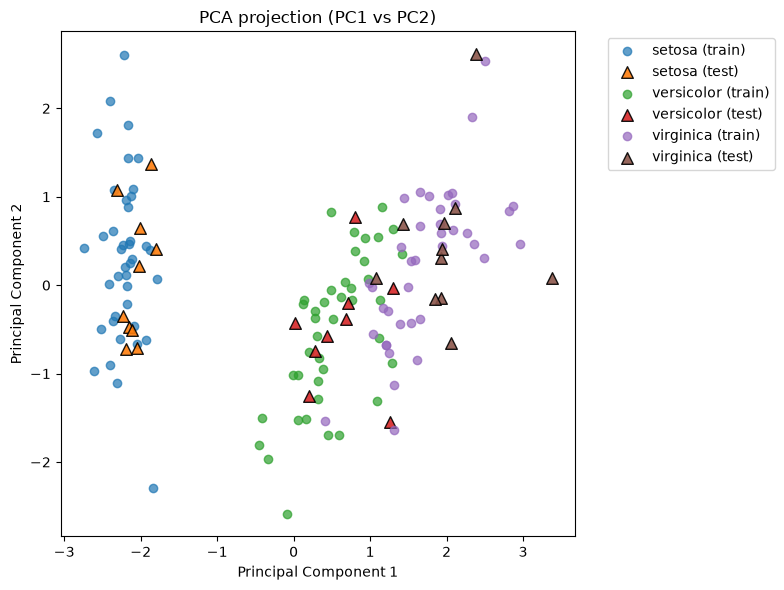

In [10]:
# 2D scatter of first two principal components
if n_components >= 2:
    plt.figure(figsize=(8,6))
    for cls, name in enumerate(data.target_names):
        # train points for this class
        idx_train = (y_train == cls).to_numpy()
        plt.scatter(X_train_pca[idx_train, 0], X_train_pca[idx_train, 1],
                    marker='o', alpha=0.7, label=f"{name} (train)")

        # test points for this class
        idx_test = (y_test == cls).to_numpy()
        plt.scatter(X_test_pca[idx_test, 0], X_test_pca[idx_test, 1],
                    marker='^', edgecolors='k', s=70, alpha=0.9, label=f"{name} (test)")

    plt.xlabel('Principal Component 1')
    plt.ylabel('Principal Component 2')
    plt.title('PCA projection (PC1 vs PC2)')
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')  # put legend to the right
    plt.tight_layout()
    plt.show()
else:
    print("n_components < 2 — no 2D scatter to show.")

In [11]:
# pipeline example (scaling + PCA + classifier) - fit only on training data
from sklearn.pipeline import make_pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

pipe = make_pipeline(StandardScaler(), PCA(n_components=2), LogisticRegression(random_state=42))
pipe.fit(X_train, y_train)                  # pipeline fits scaler+PCA on train internally
y_pred = pipe.predict(X_test)
print("Test accuracy (pipeline w/ PCA(2)):", accuracy_score(y_test, y_pred))

Test accuracy (pipeline w/ PCA(2)): 0.9


Facial Recognition using PCA and K-Nearest Neighbors

Importing Libraries

In [12]:
# Core scientific libraries
import numpy as np
import matplotlib.pyplot as plt

# Data handling
from sklearn.datasets import fetch_lfw_people 

# Preprocessing & dimensionality reduction
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler  # if not using whiten=True

# Model
from sklearn.neighbors import KNeighborsClassifier

# Evaluation
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

# Visualization 
import seaborn as sns   # for heatmaps and enhanced plots
import matplotlib.pyplot as plt

In [13]:
# Load the LFW dataset with faces having at least 60 images
faces = fetch_lfw_people(min_faces_per_person=60, resize=0.4)
X, y = faces.data, faces.target
images = faces.images
target_names = faces.target_names

c:\Users\Nicole Kasiva\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\datasets\_base.py:1522: UserWarning: Retry downloading from url: https://ndownloader.figshare.com/files/5976012
  warnings.warn(f"Retry downloading from url: {remote.url}")


In [14]:
# Display shape information
dataset_info = {
    "X_shape": X.shape,
    "image_shape": images[0].shape,
    "num_classes": len(target_names)
}
dataset_info

{'X_shape': (1348, 1850), 'image_shape': (50, 37), 'num_classes': 8}

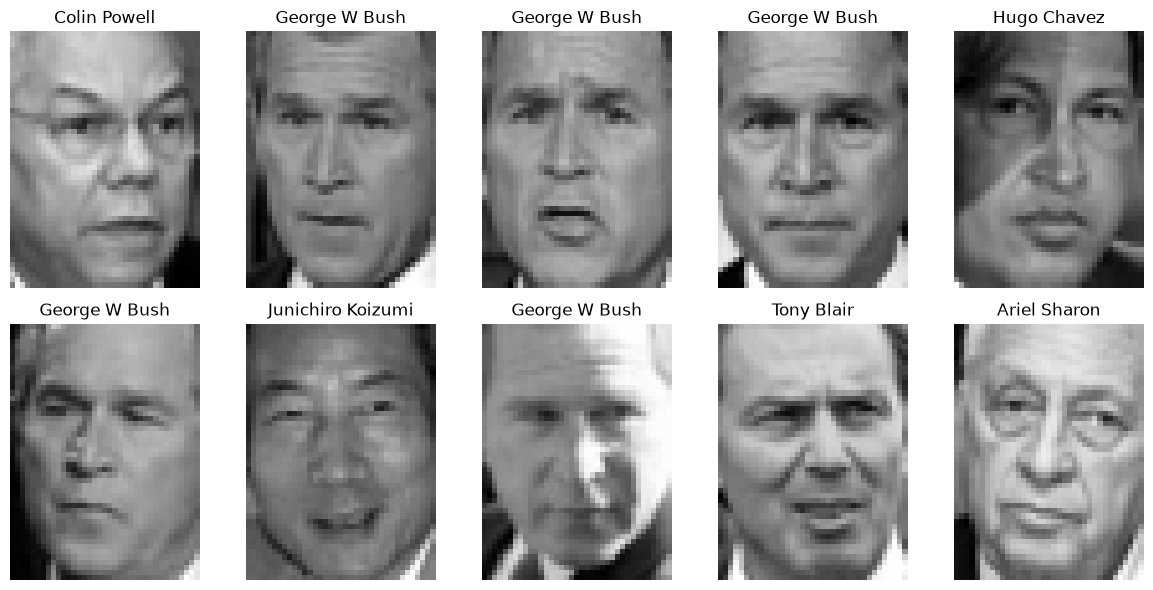

In [15]:
# Show the first few faces
fig, axes = plt.subplots(2, 5, figsize=(12, 6))
for i, ax in enumerate(axes.flat):
    ax.imshow(images[i], cmap="gray")
    ax.set_title(target_names[y[i]])
    ax.axis("off")

plt.tight_layout()
plt.show()

In [16]:
print("People being recognized:")
for i, name in enumerate(target_names):
    print(f"{i}: {name}")

People being recognized:
0: Ariel Sharon
1: Colin Powell
2: Donald Rumsfeld
3: George W Bush
4: Gerhard Schroeder
5: Hugo Chavez
6: Junichiro Koizumi
7: Tony Blair


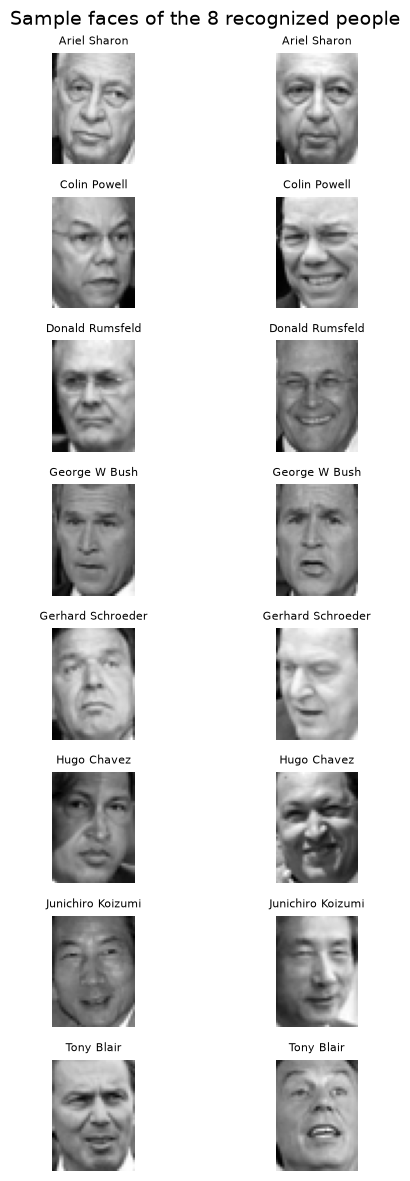

In [17]:
# Plot first 2 faces for each person
fig, axes = plt.subplots(len(target_names), 2, figsize=(6, 12))

for person_id, person_name in enumerate(target_names):
    # Find indices of images belonging to this person
    person_idx = np.where(y == person_id)[0][:2]  # take first 2
    for j, idx in enumerate(person_idx):
        ax = axes[person_id, j]
        ax.imshow(images[idx], cmap="gray")
        ax.set_title(person_name, fontsize=8)
        ax.axis("off")

plt.suptitle("Sample faces of the 8 recognized people", fontsize=14)
plt.tight_layout()

In [18]:
from sklearn.decomposition import PCA

# Step 1: Initialize PCA (keep 100 components for example)
pca = PCA(n_components=100, svd_solver='randomized', whiten=True)

# Step 2: Fit PCA on the face dataset
X_pca = pca.fit_transform(X)

print("Original shape:", X.shape)
print("Transformed shape:", X_pca.shape)

Original shape: (1348, 1850)
Transformed shape: (1348, 100)


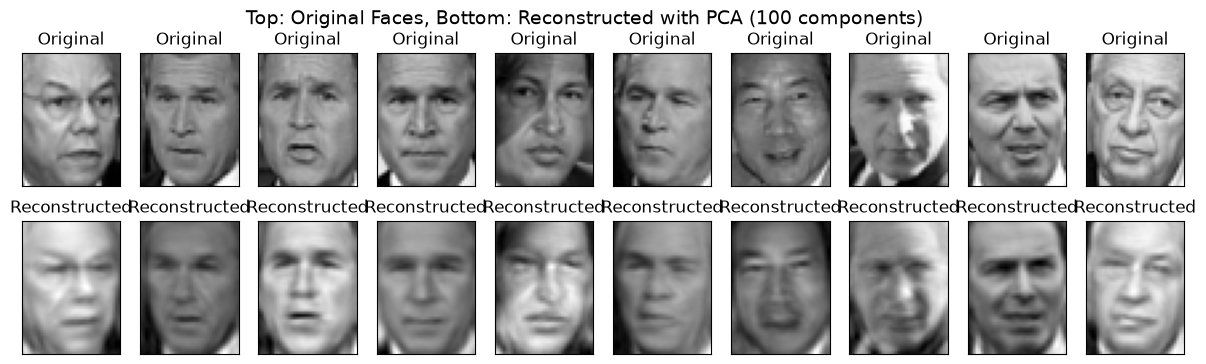

In [19]:
# Step 3: Reconstruct some faces from PCA components
X_reconstructed = pca.inverse_transform(X_pca)

# Show a comparison of original vs reconstructed faces
fig, axes = plt.subplots(2, 10, figsize=(15, 4),
                         subplot_kw={'xticks':[], 'yticks':[]})

for i in range(10):
    # Original
    axes[0, i].imshow(images[i], cmap="gray")
    axes[0, i].set_title("Original")

    # Reconstructed
    axes[1, i].imshow(X_reconstructed[i].reshape(images[0].shape), cmap="gray")
    axes[1, i].set_title("Reconstructed")

plt.suptitle("Top: Original Faces, Bottom: Reconstructed with PCA (100 components)", fontsize=14)
plt.show()

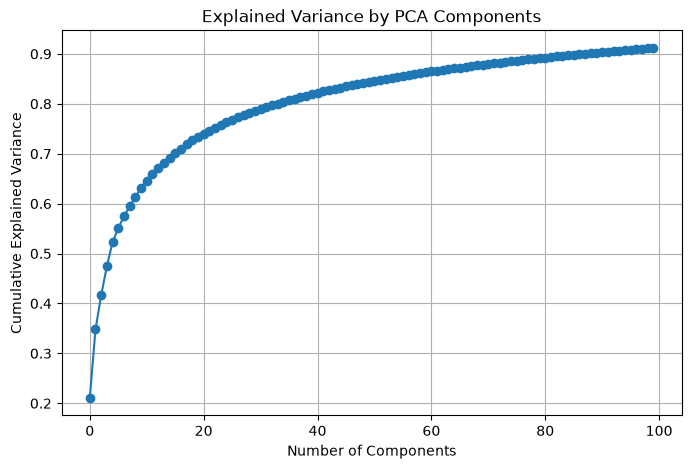

In [20]:
# Explained variance ratio (how much info each PC keeps)
explained_variance = np.cumsum(pca.explained_variance_ratio_)

plt.figure(figsize=(8,5))
plt.plot(explained_variance, marker='o')
plt.xlabel("Number of Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("Explained Variance by PCA Components")
plt.grid(True)
plt.show()

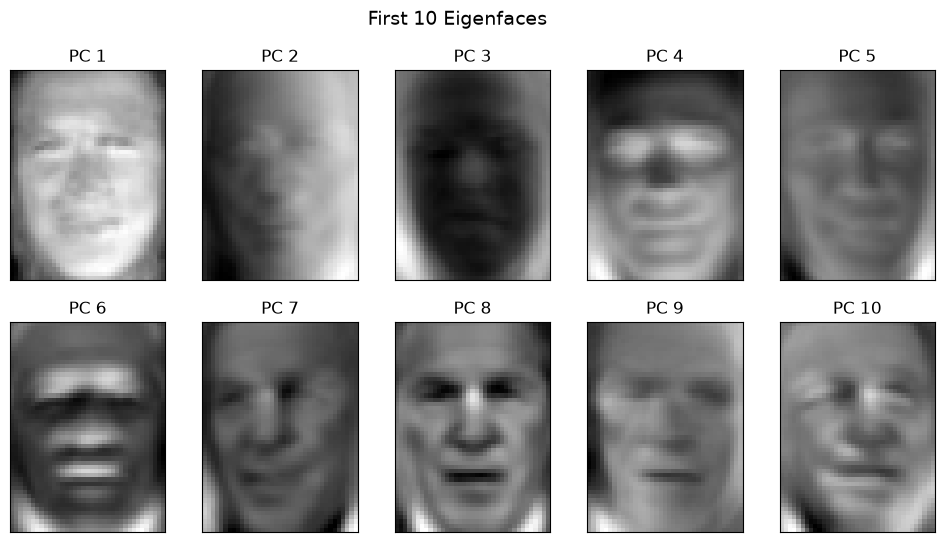

In [21]:
fig, axes = plt.subplots(2, 5, figsize=(12, 6),
                         subplot_kw={'xticks':[], 'yticks':[]})

for i, ax in enumerate(axes.flat):
    ax.imshow(pca.components_[i].reshape(images[0].shape), cmap="gray")
    ax.set_title(f"PC {i+1}")

plt.suptitle("First 10 Eigenfaces", fontsize=14)
plt.show()

In [22]:
#Model using KNN
# Baseline KNN in PCA space (proper: PCA fitted on train only)
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.decomposition import PCA
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

In [23]:
# 1) Train/test split (stratified)
X_train, X_test, y_train, y_test, imgs_train, imgs_test = train_test_split(
    X, y, images, test_size=0.20, random_state=42, stratify=y
)
print("Train shape:", X_train.shape, "Test shape:", X_test.shape)

Train shape: (1078, 1850) Test shape: (270, 1850)


In [24]:
# 2) Fit PCA on training set only
n_components = 100
pca_train = PCA(n_components=n_components, svd_solver='randomized', whiten=True, random_state=42)
X_train_pca = pca_train.fit_transform(X_train)
X_test_pca = pca_train.transform(X_test)

print("PCA fitted on train. Shapes ->", X_train_pca.shape, X_test_pca.shape)

PCA fitted on train. Shapes -> (1078, 100) (270, 100)


In [25]:
# 3) Train baseline KNN (k=5)
knn = KNeighborsClassifier(n_neighbors=5, weights='uniform')
knn.fit(X_train_pca, y_train)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",5
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance<https://docs.scipy.org/doc/scipy/reference/spatial.distance.html>`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.Doesn't affect :meth:`fit` method.",None
Name,Type,Value
"classes_ classes_: array of shape (n_classes,)Class labels known to the classifier","ndarray[int64](8,)","[0,1,2,...,5,6,7]"
"effective_metric_ effective_metric_: str or callbleThe distance metric used. It will be same as the `metric` parameteror a synonym of it, e.g. 'euclidean' if the `metric` parameter set to'minkowski' and `p` parameter set to 2.",str,'eu...an'


In [26]:
# 4) Predict & evaluate
y_pred = knn.predict(X_test_pca)
acc = accuracy_score(y_test, y_pred)
print(f"Baseline KNN accuracy (k=5) in PCA space: {acc:.4f}\n")
print("Classification report:\n")
print(classification_report(y_test, y_pred, target_names=target_names))

Baseline KNN accuracy (k=5) in PCA space: 0.6630

Classification report:

                   precision    recall  f1-score   support

     Ariel Sharon       0.43      0.38      0.40        16
     Colin Powell       0.73      0.77      0.75        47
  Donald Rumsfeld       0.54      0.29      0.38        24
    George W Bush       0.64      0.93      0.76       106
Gerhard Schroeder       0.71      0.23      0.34        22
      Hugo Chavez       0.88      0.50      0.64        14
Junichiro Koizumi       0.88      0.58      0.70        12
       Tony Blair       0.71      0.41      0.52        29

         accuracy                           0.66       270
        macro avg       0.69      0.51      0.56       270
     weighted avg       0.67      0.66      0.64       270



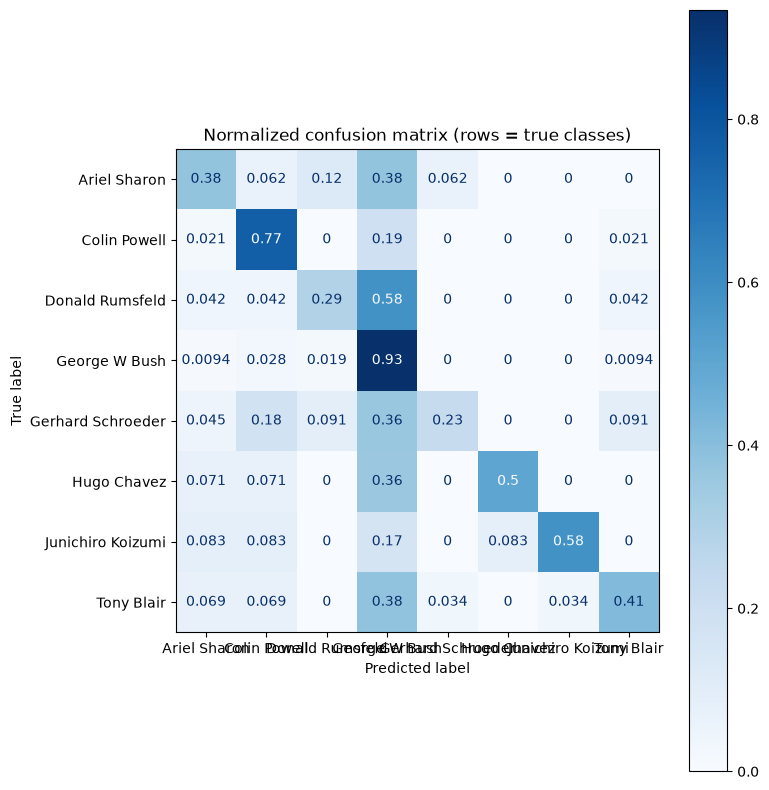

In [27]:
# 5) Confusion matrix (normalized by true class)
cm = confusion_matrix(y_test, y_pred, normalize='true')
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=target_names)
fig, ax = plt.subplots(figsize=(8,8))
disp.plot(ax=ax, cmap='Blues', colorbar=True)
plt.title("Normalized confusion matrix (rows = true classes)")
plt.tight_layout()
plt.show()

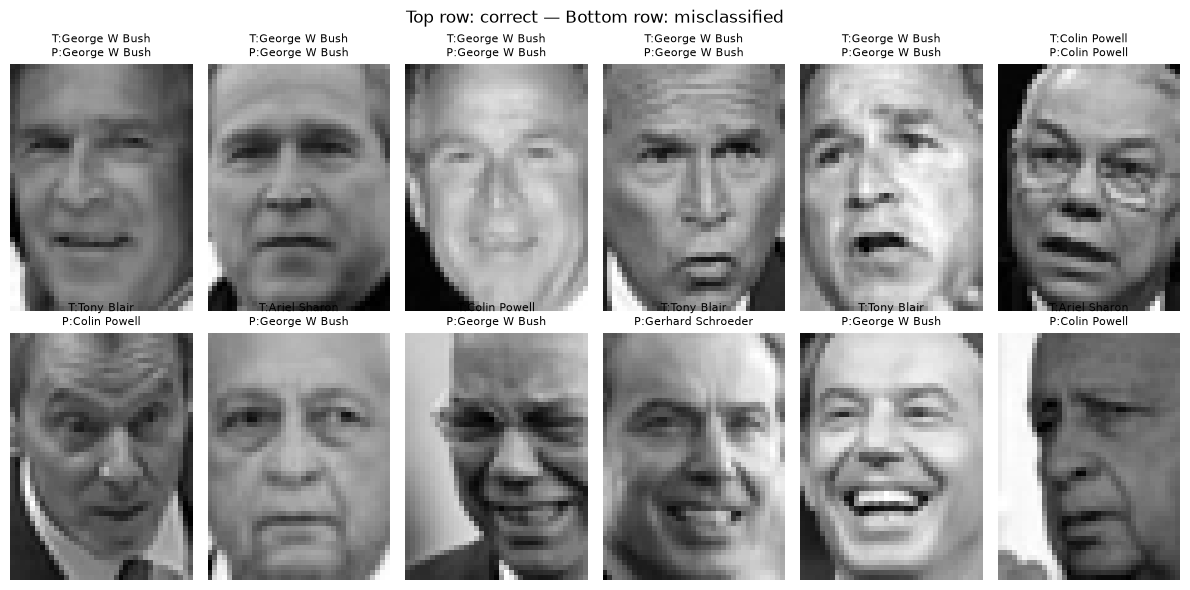

In [28]:
# 6) Show some correct vs misclassified examples
correct_idxs = np.where(y_pred == y_test)[0]
wrong_idxs   = np.where(y_pred != y_test)[0]

n_show = min(6, len(correct_idxs), len(wrong_idxs))
plt.figure(figsize=(12, 6))
for i in range(n_show):
    idx = correct_idxs[i]
    ax = plt.subplot(2, n_show, i+1)
    ax.imshow(imgs_test[idx], cmap='gray'); ax.axis('off')
    ax.set_title(f"T:{target_names[y_test[idx]]}\nP:{target_names[y_pred[idx]]}", fontsize=8)

for i in range(n_show):
    idx = wrong_idxs[i]
    ax = plt.subplot(2, n_show, n_show + i + 1)
    ax.imshow(imgs_test[idx], cmap='gray'); ax.axis('off')
    ax.set_title(f"T:{target_names[y_test[idx]]}\nP:{target_names[y_pred[idx]]}", fontsize=8)

plt.suptitle("Top row: correct — Bottom row: misclassified")
plt.tight_layout()
plt.show()


Incremental PCA
Incremental principal component analysis (IPCA) is typically used as a replacement for principal component analysis (PCA) when the dataset to be decomposed is too large to fit in memory.

Instead of computing PCA on the entire dataset at once, IPCA processes the data in mini-batches (chunks) and incrementally updates the principal components.

Why use Incremental PCA?
Standard PCA requires loading the full dataset into memory to compute the covariance matrix and perform SVD.
For very large datasets (e.g., millions of samples, high-dimensional images), this becomes impossible.
IPCA avoids memory issues by:
Splitting data into smaller chunks.
Updating the decomposition incrementally.
Examples of Incremental PCA (IPCA)
Face Recognition on Large Image Datasets
Datasets like LFW (Labeled Faces in the Wild) or company security camera logs can have millions of face images.
Each image (say 100×100 pixels) = 10,000 features. With millions of images, that’s terabytes of data.
Challenge: Regular PCA can’t load all images into memory at once.
Solution: Use Incremental PCA:
Load a few thousand images at a time.
Update the PCA components batch by batch.
Reduce image dimensions before applying classification (e.g., SVM, KNN) for face recognition.
Credit Card Fraud Detection
Banks process billions of transactions daily.
Each transaction has many features (amount, time, location, merchant type, device ID, etc.).
Challenge: Data is too big for in-memory PCA.
Solution: IPCA reduces dimensionality batch by batch, making the data manageable for anomaly detection algorithms.
Medical Imaging (MRI/CT Scans)
Hospitals store massive amounts of MRI or CT scan images (each scan can be 3D and high-resolution).
Researchers use PCA for compression/feature extraction.
Challenge: Too many images to load at once.
Solution: IPCA processes scans incrementally, extracting key features for diagnosis or research.

In [29]:
from sklearn.decomposition import IncrementalPCA
from sklearn.datasets import load_digits
from sklearn.preprocessing import StandardScaler
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix
import seaborn as sns

# Train/test split
from sklearn.model_selection import train_test_split

In [30]:
# Load dataset
digits = load_digits()
X = digits.data      
y = digits.target

In [31]:
print("X shape:", X.shape)   # features
print("y shape:", y.shape)   # labels
print("Image shape:", digits.images[0].shape)

X shape: (1797, 64)
y shape: (1797,)
Image shape: (8, 8)


In [32]:
print("Labels:", y[:20])

Labels: [0 1 2 3 4 5 6 7 8 9 0 1 2 3 4 5 6 7 8 9]


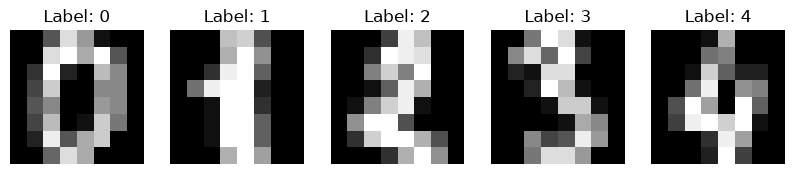

In [33]:
fig, axes = plt.subplots(1, 5, figsize=(10, 3))
for i, ax in enumerate(axes):
    ax.imshow(digits.images[i], cmap='gray')
    ax.set_title(f"Label: {y[i]}")
    ax.axis("off")
plt.show()

In [ ]:
#distribution of digits
unique, counts = np.unique(y, return_counts=True)
digit_distribution = dict(zip(unique, counts))
print(digit_distribution)

In [ ]:
#standardize the data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)